# Decision Tree Classification
In this notebook, we will walk through building a Decision Tree classifier
using the Titanic dataset. Decision trees are non-parametric models that
can capture nonlinear relationships by recursively splitting the data.
____
We'll cover:
1. Loading and inspecting the dataset.
2. Preprocessing: Handling missing values and encoding categorical data.
3. Splitting the data into training and testing sets.
4. Training a Decision Tree model.
5. Evaluating the model's performance with accuracy, confusion matrix, and a classification report.
6. Visualizing the decision tree.
7. Analyzing model performance using ROC curve and AUC.

## **Step 1: Load and Inspect the Data**

We use the Titanic dataset available from seaborn, which includes details about passengers. This dataset is widely used for classification tasks.

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Load Titanic dataset in seaborn
data = sns.load_dataset('titanic')

# Inspect the dataset
print(data.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### **Step 2: Data Preprocessing**

Our next step is to prepare the data for modeling:

- **Handling Missing Values:** (OPTIONAL FOR DECISION TREES)
   Here, the line for dropping rows with missing 'age' is commented out.
   Depending on your needs, you might choose to drop these rows or use imputation.

- **Encoding Categorical Variables:**
   Decision tree algorithms can handle numerical inputs, so we convert
   categorical variables (e.g., `sex`) into numeric format using one-hot encoding.

*Note: We use drop_first=True to avoid the dummy variable trap.*

In [3]:
# Handling missing values (optional for decision trees)
data.dropna(subset=['age'], inplace=True) # Need to include of logistic regression, but not decision trees

# Encoding categorical variables
df = pd.get_dummies(data, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"


# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df['survived']

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


### **Step 3: Splitting the Data**

We split the dataset into training and testing sets. The training set is used to build the decision tree model, while the testing set is used to evaluate its performance.

In [4]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42)

### **Step 4: Train the Decision Tree Model**

We initialize and train a Decision Tree classifier.
**Why Decision Trees?**
- They are intuitive and easy to interpret.
- They capture non-linear relationships without needing feature scaling.

Here, we use default parameters, but tuning (e.g., max_depth, min_samples_split) can improve performance and prevent overfitting.

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train tree classification model
model = DecisionTreeClassifier(random_state = 42,
                               max_depth = 4)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### **Step 5: Evaluate the Model**

We now assess our model’s performance on the test data using several metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Confusion Matrix:** Displays the number of correct and incorrect predictions.
- **Classification Report:** Provides precision, recall, and F1-score, which help in understanding performance per class.

In [7]:
model.predict(X_test)

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [ ]:

# Predict on test data

# Calculate accuracy


# Generate confusion matrix


# Display classification report


### **Step 6: Visualizing the Decision Tree**

One of the advantages of decision trees is their interpretability. We can visualize the tree structure using the graphviz library.
The visualization shows:
- Splitting criteria at each node.
- Feature names used for splits.
- Class distributions within the nodes.

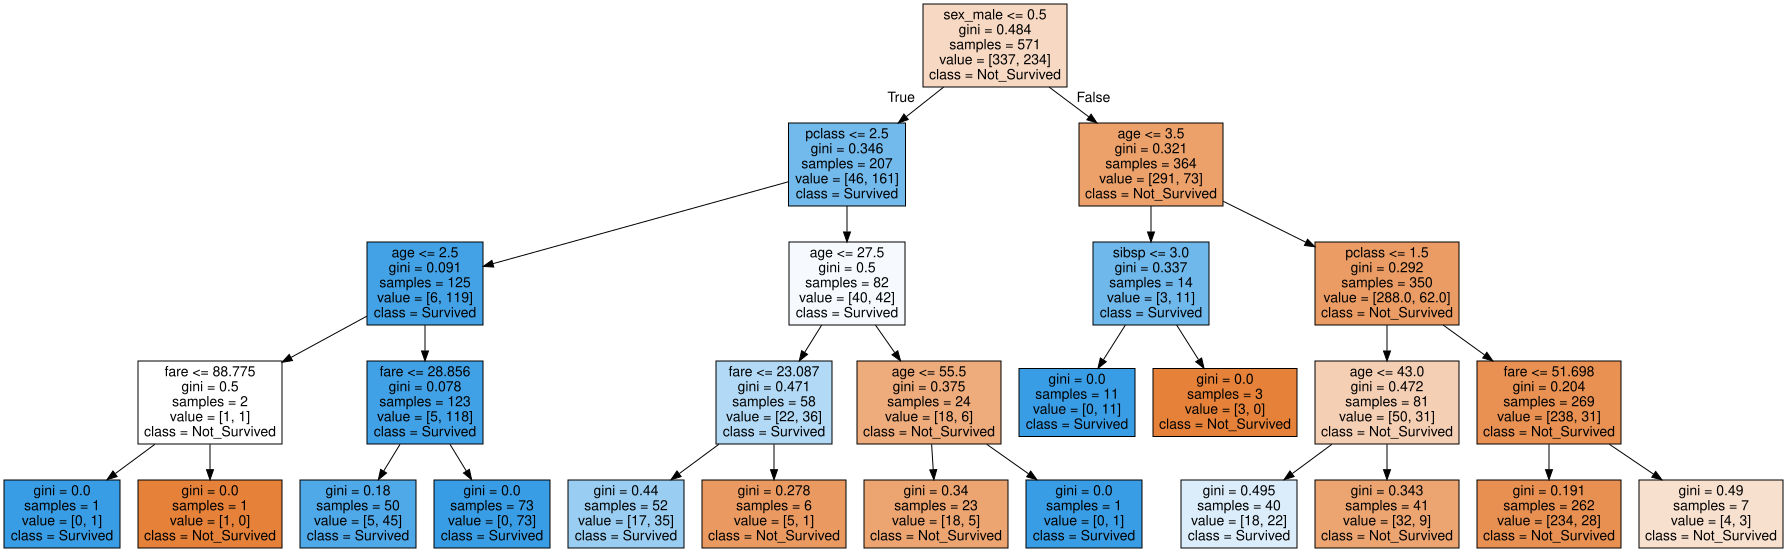

In [12]:
# Import graphviz and export the decision tree to dot format for visualization
import graphviz
from sklearn import tree
# Ensure to import the tree module from sklearn
dot_data = tree.export_graphviz(model, feature_names = X_train.columns,
                                class_names = ['Not_Survived', 'Survived'],
                                filled = True)


# Generate and display the decision tree graph
graphviz.Source(dot_data)

### Explanation of Nodes

* `pclass <= 2.5` — **The Split Condition**. If the passenger's class is ≤ 2.5 (i.e., 1st or 2nd class), go left; otherwise go right.
* `gini = 0.346` — **The Gini Impurity**. Lower means purer; 0.346 indicates moderate mixing of the two classes.
* `samples = 207` — The number of **training samples** that reached this node.
* `value = [46, 161]` — **The Class Distribution**: 46 samples in class 0 (Did Not Survive) and 161 in class 1 (Survived).
* `class = Survived` — **The Majority-Class Prediction**. Since 161 > 46, it predicts Survived.